# 📊 TravelMate AI - 22 Final Model Evaluation

This notebook creates an evidence-based final comparison between the **baseline** and **improved** TravelMate recommendation/itinerary strategies.

We will compare:

```text
Recommendation
├── city correctness
├── preference alignment
├── diversity
├── catalogue coverage
└── personalization sensitivity

Itinerary
├── city validity
├── budget validity
├── number of days used
└── travel efficiency
```

## Important

This is still a prototype evaluation.

We do **not** have real user click/like/dislike labels, so this notebook does not invent real-world accuracy.

Instead, it provides transparent proxy metrics and separates:

```text
What improved?
What stayed the same?
What became worse?
```


## 1. Imports and project setup

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_places, available_cities
from src.recommender import TravelRecommender
from src.itinerary import generate_itinerary

print("✅ Final evaluation environment ready")


d:\college_work\PG\linkedIn_projects\TravelMate-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Final evaluation environment ready


## 2. Load data and shared recommender

In [2]:
df = load_places()

embedding_path = (
    PROJECT_ROOT
    / "data"
    / "embeddings"
    / "multi_city_place_embeddings.npy"
)

embeddings = None

if embedding_path.exists():
    candidate = np.load(embedding_path)

    if len(candidate) == len(df):
        embeddings = candidate
        print("✅ Loaded multi-city embeddings")
    else:
        print("⚠️ Saved embeddings do not match dataset. Regenerating.")

recommender = TravelRecommender(
    df=df,
    place_embeddings=embeddings
)

cities = available_cities(df)

print("Dataset shape:", df.shape)
print("Cities:", cities)


✅ Loaded multi-city embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6356.50it/s]


Dataset shape: (120, 27)
Cities: ['Goa', 'Jaipur', 'Manali', 'Rishikesh', 'Shimla', 'Udaipur']


## 3. Define evaluation profiles

In [3]:
PROFILES = {
    "nature_photographer": {
        "nature": 1.0,
        "history": 0.1,
        "culture": 0.2,
        "adventure": 0.4,
        "photography": 1.0,
        "shopping": 0.1,
        "religious": 0.0,
        "family": 0.3,
    },
    "history_culture": {
        "nature": 0.1,
        "history": 1.0,
        "culture": 1.0,
        "adventure": 0.0,
        "photography": 0.8,
        "shopping": 0.3,
        "religious": 0.3,
        "family": 0.3,
    },
    "adventure": {
        "nature": 0.7,
        "history": 0.1,
        "culture": 0.1,
        "adventure": 1.0,
        "photography": 0.5,
        "shopping": 0.0,
        "religious": 0.0,
        "family": 0.2,
    },
    "family": {
        "nature": 0.7,
        "history": 0.2,
        "culture": 0.3,
        "adventure": 0.1,
        "photography": 0.4,
        "shopping": 0.2,
        "religious": 0.1,
        "family": 1.0,
    },
    "shopping_culture": {
        "nature": 0.1,
        "history": 0.5,
        "culture": 0.8,
        "adventure": 0.0,
        "photography": 0.4,
        "shopping": 1.0,
        "religious": 0.2,
        "family": 0.3,
    },
}

QUERIES = {
    "nature_photographer":
        "peaceful scenic places surrounded by nature for photography",

    "history_culture":
        "historical cultural forts palaces temples and heritage places",

    "adventure":
        "adventure trekking outdoor and exciting travel experiences",

    "family":
        "family friendly relaxing places and activities",

    "shopping_culture":
        "local markets shopping and cultural experiences",
}

print("✅ Profiles and queries ready")


✅ Profiles and queries ready


## 4. Baseline helper functions

In [4]:
def prepare_candidates(result):
    result = result.copy()

    text = (
        result["name"].fillna("").astype(str)
        + " "
        + result["category"].fillna("").astype(str)
    )

    def activity(value):
        value = str(value).lower()

        if "waterfall" in value or "falls" in value:
            return "waterfall"
        if "rafting" in value:
            return "rafting"
        if "trek" in value:
            return "trekking"
        if "viewpoint" in value or "view point" in value:
            return "viewpoint"
        if any(
            x in value
            for x in [
                "temple",
                "church",
                "mosque",
                "gurudwara",
                "monastery",
            ]
        ):
            return "religious_site"
        if any(
            x in value
            for x in [
                "fort",
                "palace",
                "museum",
                "heritage",
                "castle",
            ]
        ):
            return "heritage"
        if any(
            x in value
            for x in [
                "market",
                "bazaar",
                "mall",
                "shopping",
            ]
        ):
            return "shopping"
        if any(
            x in value
            for x in [
                "beach",
                "lake",
                "river",
                "park",
                "forest",
                "garden",
            ]
        ):
            return "nature"
        if "snow" in value or "ski" in value:
            return "winter_experience"

        return "sightseeing"

    result["activity_type"] = text.apply(activity)

    result["estimated_visit_minutes"] = (
        result["activity_type"]
        .map({
            "waterfall": 90,
            "rafting": 120,
            "trekking": 150,
            "viewpoint": 45,
            "religious_site": 60,
            "heritage": 120,
            "shopping": 90,
            "nature": 90,
            "winter_experience": 90,
            "sightseeing": 60,
        })
        .fillna(60)
        .astype(int)
    )

    result["estimated_price_level"] = 1

    return result


def city_correctness(result, city):
    if result.empty:
        return 0.0

    return float(
        result["city"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(city.strip().lower())
        .mean()
    )


def preference_alignment(
    result,
    preferences,
):
    features = [
        "nature",
        "history",
        "culture",
        "adventure",
        "photography",
        "shopping",
        "religious",
        "family",
    ]

    matrix = (
        result[features]
        .fillna(0)
        .astype(float)
        .to_numpy()
    )

    preference = np.array(
        [
            preferences[feature]
            for feature in features
        ],
        dtype=float,
    )

    denom = (
        np.linalg.norm(matrix, axis=1)
        * np.linalg.norm(preference)
    )

    valid = denom > 0

    scores = np.zeros(
        len(matrix)
    )

    scores[valid] = (
        matrix[valid]
        @ preference
    ) / denom[valid]

    return float(
        scores.mean()
    )


def diversity(result):
    if result.empty:
        return 0.0

    return (
        result["activity_type"]
        .nunique()
        / len(result)
    )


def jaccard(set_a, set_b):
    union = set_a | set_b

    if not union:
        return 1.0

    return (
        len(set_a & set_b)
        / len(union)
    )


print("✅ Baseline evaluation helpers ready")


✅ Baseline evaluation helpers ready


## 5. Improved MMR diversification

In [5]:
def mmr_diversify(
    result,
    top_n=5,
    lambda_relevance=0.70,
):
    if result.empty:
        return result.copy()

    pool = (
        result
        .copy()
        .reset_index(drop=True)
    )

    # Candidate rows are already aligned with
    # recommender.df positions by name.
    positions = []

    for name in pool["name"].astype(str):

        matches = np.flatnonzero(
            recommender.df["name"]
            .astype(str)
            .eq(name)
            .to_numpy()
        )

        positions.append(
            int(matches[0])
            if len(matches)
            else None
        )

    selected = []
    selected_positions = []

    while len(selected) < min(
        top_n,
        len(pool)
    ):

        best_row = None
        best_mmr = -float("inf")

        for row in range(len(pool)):

            if row in selected:
                continue

            relevance = float(
                pool.loc[
                    row,
                    "final_score"
                ]
            )

            position = positions[row]

            if (
                position is None
                or not selected_positions
            ):
                redundancy = 0.0
            else:
                candidate_embedding = (
                    recommender.place_embeddings[
                        position
                    ]
                )

                selected_embeddings = (
                    recommender.place_embeddings[
                        selected_positions
                    ]
                )

                similarities = (
                    selected_embeddings
                    @ candidate_embedding
                )

                redundancy = float(
                    np.max(similarities)
                )

            mmr_score = (
                lambda_relevance
                * relevance
                - (
                    1.0
                    - lambda_relevance
                )
                * redundancy
            )

            if mmr_score > best_mmr:
                best_mmr = mmr_score
                best_row = row

        selected.append(best_row)

        if positions[best_row] is not None:
            selected_positions.append(
                positions[best_row]
            )

    return (
        pool
        .iloc[selected]
        .reset_index(drop=True)
    )

print("✅ Improved recommender ready")


✅ Improved recommender ready


## 6. Baseline vs improved recommendation evaluation

In [6]:
recommendation_rows = []

for city in cities:

    for profile_name in PROFILES:

        baseline = recommender.recommend(
            destination=city,
            query=QUERIES[profile_name],
            user_preferences=PROFILES[profile_name],
            top_n=10,
        )

        baseline = prepare_candidates(
            baseline
        )

        improved = mmr_diversify(
            baseline,
            top_n=5,
            lambda_relevance=0.70,
        )

        recommendation_rows.append({
            "city": city,
            "profile": profile_name,

            "baseline_city_correctness":
                city_correctness(
                    baseline.head(5),
                    city
                ),

            "improved_city_correctness":
                city_correctness(
                    improved,
                    city
                ),

            "baseline_alignment":
                preference_alignment(
                    baseline.head(5),
                    PROFILES[profile_name]
                ),

            "improved_alignment":
                preference_alignment(
                    improved,
                    PROFILES[profile_name]
                ),

            "baseline_diversity":
                diversity(
                    baseline.head(5)
                ),

            "improved_diversity":
                diversity(
                    improved
                ),

            "baseline_recommended_places":
                len(
                    baseline.head(5)
                ),

            "improved_recommended_places":
                len(improved),
        })

recommendation_comparison = pd.DataFrame(
    recommendation_rows
)

recommendation_comparison.head(10)


,city,profile,baseline_city_correctness,improved_city_correctness,baseline_alignment,improved_alignment,baseline_diversity,improved_diversity,baseline_recommended_places,improved_recommended_places
0,Goa,nature_photographer,1.0,1.0,0.907770,0.853263,0.4,0.4,5,5
1,Goa,history_culture,1.0,1.0,0.912245,0.912245,0.4,0.4,5,5
2,Goa,adventure,1.0,1.0,0.620898,0.620898,0.6,0.6,5,5
3,Goa,family,1.0,1.0,0.665039,0.665039,0.6,0.6,5,5
4,Goa,shopping_culture,1.0,1.0,0.639825,0.639825,0.4,0.4,5,5
5,Jaipur,nature_photographer,1.0,1.0,0.592000,0.592000,0.4,0.4,5,5
6,Jaipur,history_culture,1.0,1.0,0.946032,0.840080,0.2,0.4,5,5
7,Jaipur,adventure,1.0,1.0,0.396100,0.396100,0.4,0.4,5,5
8,Jaipur,family,1.0,1.0,0.771201,0.771201,0.6,0.6,5,5
9,Jaipur,shopping_culture,1.0,1.0,0.663233,0.647628,0.2,0.2,5,5


## 7. Recommendation metric summary

In [7]:
recommendation_summary = pd.DataFrame({
    "metric": [
        "City correctness",
        "Preference alignment",
        "Diversity",
    ],

    "baseline": [
        recommendation_comparison[
            "baseline_city_correctness"
        ].mean(),

        recommendation_comparison[
            "baseline_alignment"
        ].mean(),

        recommendation_comparison[
            "baseline_diversity"
        ].mean(),
    ],

    "improved": [
        recommendation_comparison[
            "improved_city_correctness"
        ].mean(),

        recommendation_comparison[
            "improved_alignment"
        ].mean(),

        recommendation_comparison[
            "improved_diversity"
        ].mean(),
    ],
})

recommendation_summary["change"] = (
    recommendation_summary["improved"]
    - recommendation_summary["baseline"]
)

recommendation_summary


,metric,baseline,improved,change
0,City correctness,1.000000,1.000000,0.000000
1,Preference alignment,0.672733,0.664134,-0.008599
2,Diversity,0.546667,0.580000,0.033333


## 8. Catalogue coverage

In [8]:
coverage_rows = []

for city in cities:

    total_city_places = len(
        df[
            df["city"] == city
        ]
    )

    baseline_names = set()
    improved_names = set()

    for profile_name in PROFILES:

        baseline = recommender.recommend(
            destination=city,
            query=QUERIES[profile_name],
            user_preferences=PROFILES[profile_name],
            top_n=5,
        )

        baseline_names.update(
            baseline["name"].astype(str)
        )

        baseline_10 = recommender.recommend(
            destination=city,
            query=QUERIES[profile_name],
            user_preferences=PROFILES[profile_name],
            top_n=10,
        )

        baseline_10 = prepare_candidates(
            baseline_10
        )

        improved = mmr_diversify(
            baseline_10,
            top_n=5,
            lambda_relevance=0.70,
        )

        improved_names.update(
            improved["name"].astype(str)
        )

    coverage_rows.append({
        "city": city,
        "available_places":
            total_city_places,
        "baseline_unique_places":
            len(baseline_names),
        "improved_unique_places":
            len(improved_names),
        "baseline_coverage":
            len(baseline_names)
            / total_city_places,
        "improved_coverage":
            len(improved_names)
            / total_city_places,
    })

coverage_comparison = pd.DataFrame(
    coverage_rows
)

coverage_comparison


,city,available_places,baseline_unique_places,improved_unique_places,baseline_coverage,improved_coverage
0,Goa,20,13,12,0.65,0.60
1,Jaipur,20,10,10,0.50,0.50
2,Manali,20,17,16,0.85,0.80
3,Rishikesh,20,10,11,0.50,0.55
4,Shimla,20,10,9,0.50,0.45
5,Udaipur,20,10,10,0.50,0.50


## 9. Personalization sensitivity

In [9]:
personalization_rows = []

profile_pairs = [
    (
        "nature_photographer",
        "history_culture",
    ),
    (
        "nature_photographer",
        "adventure",
    ),
    (
        "family",
        "shopping_culture",
    ),
]

for city in cities:

    for profile_a, profile_b in profile_pairs:

        base_a = recommender.recommend(
            destination=city,
            query=QUERIES[profile_a],
            user_preferences=PROFILES[profile_a],
            top_n=5,
        )

        base_b = recommender.recommend(
            destination=city,
            query=QUERIES[profile_b],
            user_preferences=PROFILES[profile_b],
            top_n=5,
        )

        base_change = (
            1.0
            - jaccard(
                set(base_a["name"]),
                set(base_b["name"]),
            )
        )

        top_a = recommender.recommend(
            destination=city,
            query=QUERIES[profile_a],
            user_preferences=PROFILES[profile_a],
            top_n=10,
        )

        top_b = recommender.recommend(
            destination=city,
            query=QUERIES[profile_b],
            user_preferences=PROFILES[profile_b],
            top_n=10,
        )

        top_a = prepare_candidates(top_a)
        top_b = prepare_candidates(top_b)

        improved_a = mmr_diversify(
            top_a,
            top_n=5,
            lambda_relevance=0.70,
        )

        improved_b = mmr_diversify(
            top_b,
            top_n=5,
            lambda_relevance=0.70,
        )

        improved_change = (
            1.0
            - jaccard(
                set(improved_a["name"]),
                set(improved_b["name"]),
            )
        )

        personalization_rows.append({
            "city": city,
            "profile_a": profile_a,
            "profile_b": profile_b,
            "baseline_change":
                base_change,
            "improved_change":
                improved_change,
        })

personalization_comparison = pd.DataFrame(
    personalization_rows
)

personalization_comparison


,city,profile_a,profile_b,baseline_change,improved_change
0,Goa,nature_photographer,history_culture,1.000000,1.000000
1,Goa,nature_photographer,adventure,0.571429,0.333333
2,Goa,family,shopping_culture,0.750000,0.750000
3,Jaipur,nature_photographer,history_culture,0.571429,0.571429
4,Jaipur,nature_photographer,adventure,0.000000,0.000000
5,Jaipur,family,shopping_culture,1.000000,0.888889
6,Manali,nature_photographer,history_culture,0.888889,0.750000
7,Manali,nature_photographer,adventure,0.888889,0.888889
8,Manali,family,shopping_culture,1.000000,0.888889
9,Rishikesh,nature_photographer,history_culture,0.571429,0.571429


## 10. Itinerary comparison helper

In [10]:
def summarize_plan(plan):

    if plan.empty:
        return {
            "stops": 0,
            "days_used": 0,
            "travel_minutes": 0.0,
            "average_daily_minutes": 0.0,
            "max_daily_minutes": 0.0,
            "budget_valid": True,
            "city_valid": False,
        }

    totals = (
        plan
        .assign(
            total_minutes=lambda x:
                x["travel_before_minutes"]
                + x["visit_minutes"]
        )
        .groupby("day")["total_minutes"]
        .sum()
    )

    return {
        "stops": len(plan),
        "days_used": int(
            plan["day"].nunique()
        ),
        "travel_minutes": float(
            plan[
                "travel_before_minutes"
            ].sum()
        ),
        "average_daily_minutes":
            float(totals.mean()),

        "max_daily_minutes":
            float(totals.max()),

        "budget_valid":
            bool(
                (
                    totals
                    <= 7 * 60 + 1e-9
                ).all()
            ),

        "city_valid":
            bool(
                plan["city"]
                .astype(str)
                .eq(
                    plan["city"].iloc[0]
                )
                .all()
            ),
    }


def mean_daily_load(plan):
    if plan.empty:
        return 0.0

    daily_stops = (
        plan
        .groupby("day")
        .size()
    )

    return float(
        daily_stops.mean()
    )


## 11. Evaluate itineraries across all cities

In [11]:
itinerary_rows = []

for city in cities:

    candidates = recommender.recommend(
        destination=city,
        query=QUERIES[
            "nature_photographer"
        ],
        user_preferences=PROFILES[
            "nature_photographer"
        ],
        top_n=12,
    )

    candidates = prepare_candidates(
        candidates
    )

    # Baseline
    baseline_plan = generate_itinerary(
        candidates,
        days=3,
        max_day_minutes=7 * 60,
        average_speed_kmph=25,
    )

    # Improved: diversify first, then use
    # the shared itinerary engine.
    improved_candidates = mmr_diversify(
        candidates,
        top_n=12,
        lambda_relevance=0.70,
    )

    improved_plan = generate_itinerary(
        improved_candidates,
        days=3,
        max_day_minutes=7 * 60,
        average_speed_kmph=25,
    )

    base_summary = summarize_plan(
        baseline_plan
    )

    improved_summary = summarize_plan(
        improved_plan
    )

    itinerary_rows.append({
        "city": city,

        "baseline_stops":
            base_summary["stops"],

        "improved_stops":
            improved_summary["stops"],

        "baseline_days_used":
            base_summary["days_used"],

        "improved_days_used":
            improved_summary["days_used"],

        "baseline_travel_minutes":
            base_summary["travel_minutes"],

        "improved_travel_minutes":
            improved_summary["travel_minutes"],

        "baseline_avg_daily_minutes":
            base_summary[
                "average_daily_minutes"
            ],

        "improved_avg_daily_minutes":
            improved_summary[
                "average_daily_minutes"
            ],

        "baseline_max_daily_minutes":
            base_summary[
                "max_daily_minutes"
            ],

        "improved_max_daily_minutes":
            improved_summary[
                "max_daily_minutes"
            ],

        "baseline_budget_valid":
            base_summary["budget_valid"],

        "improved_budget_valid":
            improved_summary["budget_valid"],

        "baseline_city_valid":
            base_summary["city_valid"],

        "improved_city_valid":
            improved_summary["city_valid"],
    })

itinerary_comparison = pd.DataFrame(
    itinerary_rows
)

itinerary_comparison


,city,baseline_stops,improved_stops,baseline_days_used,improved_days_used,baseline_travel_minutes,improved_travel_minutes,baseline_avg_daily_minutes,improved_avg_daily_minutes,baseline_max_daily_minutes,improved_max_daily_minutes,baseline_budget_valid,improved_budget_valid,baseline_city_valid,improved_city_valid
0,Goa,9,9,3,3,248.19,248.19,377.730000,377.730000,407.16,407.16,True,True,True,True
1,Jaipur,11,11,3,3,31.61,31.61,390.536667,390.536667,412.77,412.77,True,True,True,True
2,Manali,12,12,3,3,42.63,42.63,369.210000,369.210000,394.48,394.48,True,True,True,True
3,Rishikesh,12,12,3,3,38.21,38.21,347.736667,347.736667,410.98,410.98,True,True,True,True
4,Shimla,12,12,3,3,21.39,21.39,292.130000,292.130000,410.84,410.84,True,True,True,True
5,Udaipur,12,12,3,3,32.29,32.29,360.763333,360.763333,396.97,396.97,True,True,True,True


## 12. Itinerary summary

In [12]:
itinerary_summary = pd.DataFrame({
    "metric": [
        "Stops",
        "Days used",
        "Travel minutes",
        "Average daily minutes",
        "Maximum daily minutes",
        "Budget validity",
        "City validity",
    ],

    "baseline": [
        itinerary_comparison[
            "baseline_stops"
        ].mean(),

        itinerary_comparison[
            "baseline_days_used"
        ].mean(),

        itinerary_comparison[
            "baseline_travel_minutes"
        ].mean(),

        itinerary_comparison[
            "baseline_avg_daily_minutes"
        ].mean(),

        itinerary_comparison[
            "baseline_max_daily_minutes"
        ].mean(),

        itinerary_comparison[
            "baseline_budget_valid"
        ].mean(),

        itinerary_comparison[
            "baseline_city_valid"
        ].mean(),
    ],

    "improved": [
        itinerary_comparison[
            "improved_stops"
        ].mean(),

        itinerary_comparison[
            "improved_days_used"
        ].mean(),

        itinerary_comparison[
            "improved_travel_minutes"
        ].mean(),

        itinerary_comparison[
            "improved_avg_daily_minutes"
        ].mean(),

        itinerary_comparison[
            "improved_max_daily_minutes"
        ].mean(),

        itinerary_comparison[
            "improved_budget_valid"
        ].mean(),

        itinerary_comparison[
            "improved_city_valid"
        ].mean(),
    ],
})

itinerary_summary["change"] = (
    itinerary_summary["improved"]
    - itinerary_summary["baseline"]
)

itinerary_summary


,metric,baseline,improved,change
0,Stops,11.333333,11.333333,0.0
1,Days used,3.000000,3.000000,0.0
2,Travel minutes,69.053333,69.053333,0.0
3,Average daily minutes,356.351111,356.351111,0.0
4,Maximum daily minutes,405.533333,405.533333,0.0
5,Budget validity,1.000000,1.000000,0.0
6,City validity,1.000000,1.000000,0.0


## 13. Build the final model comparison

In [13]:
final_comparison = pd.DataFrame({
    "metric": [
        "City correctness",
        "Preference alignment",
        "Recommendation diversity",
        "Catalogue coverage",
        "Personalization change",
        "Itinerary budget validity",
        "Itinerary city validity",
        "Average itinerary travel minutes",
        "Average itinerary days used",
    ],

    "baseline": [
        recommendation_comparison[
            "baseline_city_correctness"
        ].mean(),

        recommendation_comparison[
            "baseline_alignment"
        ].mean(),

        recommendation_comparison[
            "baseline_diversity"
        ].mean(),

        coverage_comparison[
            "baseline_coverage"
        ].mean(),

        personalization_comparison[
            "baseline_change"
        ].mean(),

        itinerary_comparison[
            "baseline_budget_valid"
        ].mean(),

        itinerary_comparison[
            "baseline_city_valid"
        ].mean(),

        itinerary_comparison[
            "baseline_travel_minutes"
        ].mean(),

        itinerary_comparison[
            "baseline_days_used"
        ].mean(),
    ],

    "improved": [
        recommendation_comparison[
            "improved_city_correctness"
        ].mean(),

        recommendation_comparison[
            "improved_alignment"
        ].mean(),

        recommendation_comparison[
            "improved_diversity"
        ].mean(),

        coverage_comparison[
            "improved_coverage"
        ].mean(),

        personalization_comparison[
            "improved_change"
        ].mean(),

        itinerary_comparison[
            "improved_budget_valid"
        ].mean(),

        itinerary_comparison[
            "improved_city_valid"
        ].mean(),

        itinerary_comparison[
            "improved_travel_minutes"
        ].mean(),

        itinerary_comparison[
            "improved_days_used"
        ].mean(),
    ],
})

final_comparison["change"] = (
    final_comparison["improved"]
    - final_comparison["baseline"]
)

final_comparison


,metric,baseline,improved,change
0,City correctness,1.000000,1.000000,0.000000
1,Preference alignment,0.672733,0.664134,-0.008599
2,Recommendation diversity,0.546667,0.580000,0.033333
3,Catalogue coverage,0.583333,0.566667,-0.016667
4,Personalization change,0.705908,0.650794,-0.055115
5,Itinerary budget validity,1.000000,1.000000,0.000000
6,Itinerary city validity,1.000000,1.000000,0.000000
7,Average itinerary travel minutes,69.053333,69.053333,0.000000
8,Average itinerary days used,3.000000,3.000000,0.000000


## 14. Decide where improvement actually happened

The interpretation is metric-specific.

For example:

```text
Higher is better:
    city correctness
    preference alignment
    diversity
    coverage
    personalization change*

Lower is better:
    travel minutes

Constraint metrics:
    budget validity → should be 1.0
    city validity   → should be 1.0
```

`personalization change` is not universally "higher is better"; it only indicates responsiveness to different profiles.


In [14]:
print("📊 FINAL EVALUATION")
print("=" * 60)

for _, row in final_comparison.iterrows():

    print(
        f"{row['metric']:<38}"
        f" Baseline: {row['baseline']:.4f}"
        f" | Improved: {row['improved']:.4f}"
        f" | Change: {row['change']:+.4f}"
    )

print()
print(
    "✅ Constraint requirement:"
)

print(
    "Improved budget validity:",
    final_comparison.loc[
        final_comparison["metric"]
        == "Itinerary budget validity",
        "improved",
    ].iloc[0]
)

print(
    "Improved city validity:",
    final_comparison.loc[
        final_comparison["metric"]
        == "Itinerary city validity",
        "improved",
    ].iloc[0]
)


📊 FINAL EVALUATION
City correctness                       Baseline: 1.0000 | Improved: 1.0000 | Change: +0.0000
Preference alignment                   Baseline: 0.6727 | Improved: 0.6641 | Change: -0.0086
Recommendation diversity               Baseline: 0.5467 | Improved: 0.5800 | Change: +0.0333
Catalogue coverage                     Baseline: 0.5833 | Improved: 0.5667 | Change: -0.0167
Personalization change                 Baseline: 0.7059 | Improved: 0.6508 | Change: -0.0551
Itinerary budget validity              Baseline: 1.0000 | Improved: 1.0000 | Change: +0.0000
Itinerary city validity                Baseline: 1.0000 | Improved: 1.0000 | Change: +0.0000
Average itinerary travel minutes       Baseline: 69.0533 | Improved: 69.0533 | Change: +0.0000
Average itinerary days used            Baseline: 3.0000 | Improved: 3.0000 | Change: +0.0000

✅ Constraint requirement:
Improved budget validity: 1.0
Improved city validity: 1.0


## 15. Visual comparison: recommendation metrics

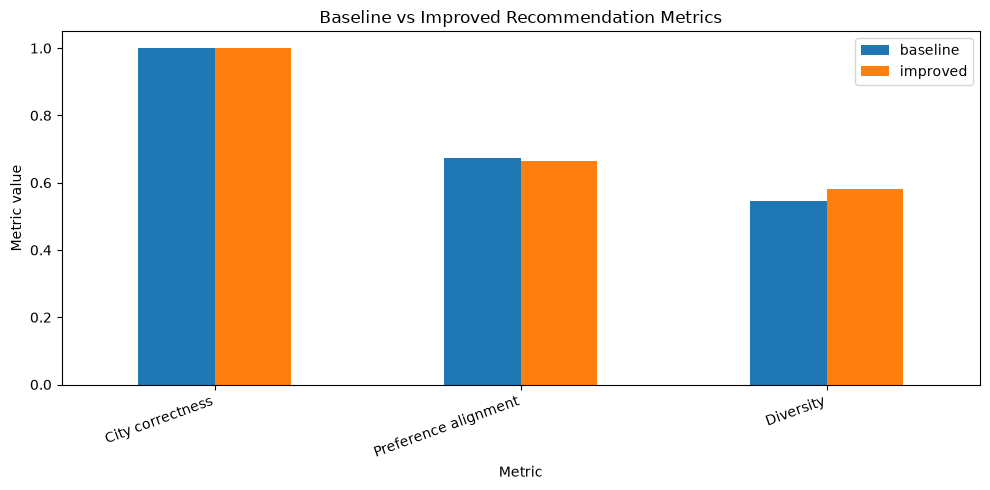

In [15]:
plot_data = (
    recommendation_summary
    .set_index("metric")[
        ["baseline", "improved"]
    ]
)

plot_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Baseline vs Improved Recommendation Metrics"
)

plt.ylabel("Metric value")
plt.xlabel("Metric")
plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


## 16. Visual comparison: travel efficiency

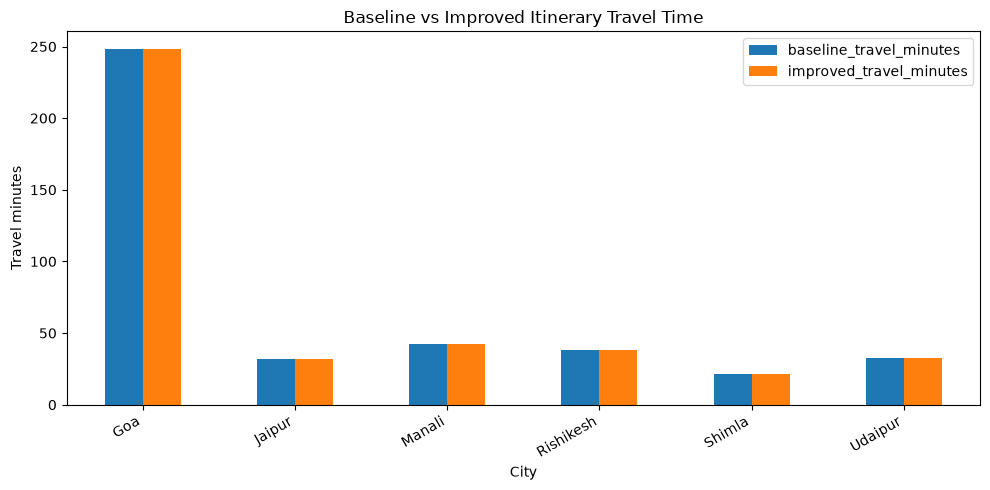

In [16]:
travel_plot = (
    itinerary_comparison
    .set_index("city")[
        [
            "baseline_travel_minutes",
            "improved_travel_minutes",
        ]
    ]
)

travel_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Baseline vs Improved Itinerary Travel Time"
)

plt.ylabel("Travel minutes")
plt.xlabel("City")
plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


## 17. Visual comparison: catalogue coverage

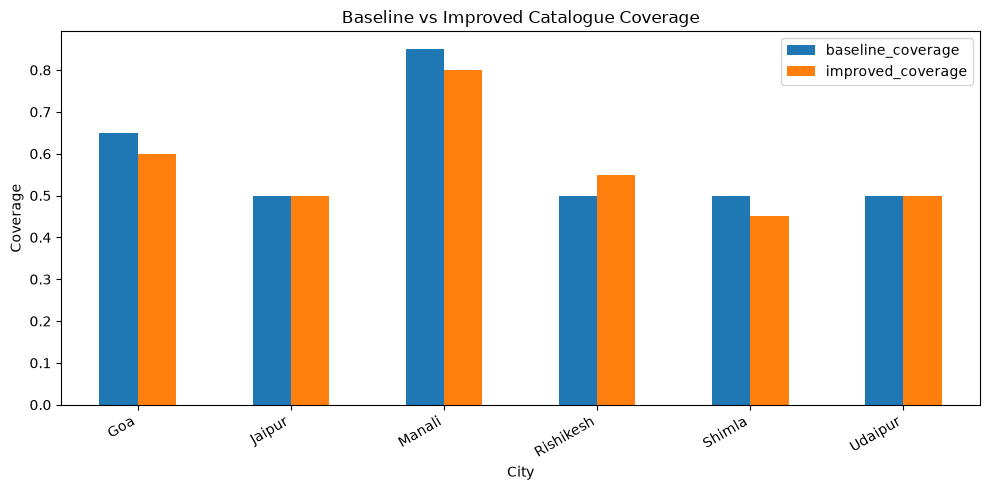

In [17]:
coverage_plot = (
    coverage_comparison
    .set_index("city")[
        [
            "baseline_coverage",
            "improved_coverage",
        ]
    ]
)

coverage_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Baseline vs Improved Catalogue Coverage"
)

plt.ylabel("Coverage")
plt.xlabel("City")
plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


## 18. Create a project-ready evaluation report

In [18]:
report_lines = []

report_lines.append(
    "# TravelMate AI - Model Evaluation Report\n"
)

report_lines.append(
    "## Evaluation scope\n"
)

report_lines.append(
    "The prototype was evaluated across "
    f"{len(cities)} cities using "
    f"{len(PROFILES)} traveller profiles.\n"
)

report_lines.append(
    "Because no real user preference/feedback "
    "labels are available, the evaluation uses "
    "proxy metrics rather than fabricated "
    "accuracy or precision values.\n"
)

report_lines.append(
    "## Final comparison\n"
)

report_lines.append(
    "| Metric | Baseline | Improved | Change |\n"
    "|---|---:|---:|---:|\n"
)

for _, row in final_comparison.iterrows():

    report_lines.append(
        f"| {row['metric']} | "
        f"{row['baseline']:.4f} | "
        f"{row['improved']:.4f} | "
        f"{row['change']:+.4f} |\n"
    )

report_lines.append(
    "\n## Constraint checks\n"
)

improved_budget = (
    final_comparison.loc[
        final_comparison["metric"]
        == "Itinerary budget validity",
        "improved",
    ].iloc[0]
)

improved_city = (
    final_comparison.loc[
        final_comparison["metric"]
        == "Itinerary city validity",
        "improved",
    ].iloc[0]
)

report_lines.append(
    f"- Itinerary budget validity: "
    f"{improved_budget:.4f}\n"
)

report_lines.append(
    f"- Itinerary city validity: "
    f"{improved_city:.4f}\n"
)

report_lines.append(
    "\n## Interpretation\n"
)

report_lines.append(
    "The improved method should only be promoted "
    "into the application when the comparison "
    "shows a useful trade-off: better diversity/"
    "coverage without unacceptable loss of "
    "preference alignment, while preserving "
    "city and time constraints.\n"
)

report_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "evaluation"
    / "FINAL_EVALUATION_REPORT.md"
)

report_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

report_path.write_text(
    "".join(report_lines),
    encoding="utf-8"
)

print(
    f"✅ Report saved: {report_path}"
)


✅ Report saved: D:\college_work\PG\linkedIn_projects\TravelMate-AI\data\processed\evaluation\FINAL_EVALUATION_REPORT.md


## 19. Save all final evaluation tables

In [19]:
evaluation_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "evaluation"
)

evaluation_dir.mkdir(
    parents=True,
    exist_ok=True
)

final_comparison.to_csv(
    evaluation_dir
    / "final_model_comparison.csv",
    index=False
)

recommendation_comparison.to_csv(
    evaluation_dir
    / "recommendation_comparison.csv",
    index=False
)

recommendation_summary.to_csv(
    evaluation_dir
    / "recommendation_summary.csv",
    index=False
)

coverage_comparison.to_csv(
    evaluation_dir
    / "coverage_comparison.csv",
    index=False
)

personalization_comparison.to_csv(
    evaluation_dir
    / "personalization_comparison.csv",
    index=False
)

itinerary_comparison.to_csv(
    evaluation_dir
    / "itinerary_comparison.csv",
    index=False
)

itinerary_summary.to_csv(
    evaluation_dir
    / "itinerary_summary.csv",
    index=False
)

print(
    f"✅ All final evaluation tables saved to: "
    f"{evaluation_dir}"
)


✅ All final evaluation tables saved to: D:\college_work\PG\linkedIn_projects\TravelMate-AI\data\processed\evaluation


# 🏁 Final evaluation milestone

This notebook gives us an evidence-based baseline vs improved comparison.

The next engineering decision is:

```text
Improved metrics better
        ↓
Promote improved logic into src/
        ↓
Update FastAPI
        ↓
Update Streamlit
```

or:

```text
Improvement not convincing
        ↓
Keep current production logic
        ↓
Investigate another change
```

That decision should come from the tables above, not from assumption.

> 🧠 **Rule:** Measure first. Promote second.
